# Exploratory Data Analysis (EDA) - Amazon Recommender System

This notebook analyzes:

- Dataset structure
- User-item interactions
- Rating distribution
- Data sparsity
- User activity and item popularity
- Long-tail behavior

These insights guide model selection and preprocessing steps.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Cleaned Dataset

In [40]:
DATA_PROCESSED = "../data/processed/"

df = pd.read_csv(DATA_PROCESSED + "cleaned_data.csv")

df.head()

,reviewerID,asin,overall,reviewText,summary,reviewTime,title,brand,category_list,category_text,description
0,A3NHUQ33CFH3VM,1118461304,5.0,Not one thing in this book seemed an obvious o...,Clear on what leads to innovation,2013-11-27,NaN,NaN,[],unknown,unknown
1,A3SK6VNBQDNBJE,1118461304,5.0,I have enjoyed Dr. Alan Gregerman's weekly blo...,Becoming more innovative by opening yourself t...,2013-11-01,NaN,NaN,[],unknown,unknown
2,A3SOFHUR27FO3K,1118461304,5.0,Alan Gregerman believes that innovation comes ...,The World from Different Perspectives,2013-10-10,NaN,NaN,[],unknown,unknown
3,A1HOG1PYCAE157,1118461304,5.0,"Alan Gregerman is a smart, funny, entertaining...",Strangers are Your New Best Friends,2013-10-09,NaN,NaN,[],unknown,unknown
4,A26JGAM6GZMM4V,1118461304,5.0,"As I began to read this book, I was again remi...","How and why it is imperative to engage, learn ...",2013-09-07,NaN,NaN,[],unknown,unknown


In [41]:
df.isnull().sum()

reviewerID          0
asin                0
overall             0
reviewText          0
summary           120
reviewTime          0
title             993
brand            5910
category_list       0
category_text       0
description         0
dtype: int64

## Dataset Overview

In [42]:
print("Shape of dataset:", df.shape)

df.info()

Shape of dataset: (590985, 11)
<class 'pandas.DataFrame'>
RangeIndex: 590985 entries, 0 to 590984
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   reviewerID     590985 non-null  str    
 1   asin           590985 non-null  str    
 2   overall        590985 non-null  float64
 3   reviewText     590985 non-null  str    
 4   summary        590865 non-null  str    
 5   reviewTime     590985 non-null  str    
 6   title          589992 non-null  str    
 7   brand          585075 non-null  str    
 8   category_list  590985 non-null  str    
 9   category_text  590985 non-null  str    
 10  description    590985 non-null  str    
dtypes: float64(1), str(10)
memory usage: 49.6 MB


### Users, Items, and Interactions

In [43]:
n_users = df["reviewerID"].nunique()
n_items = df["asin"].nunique()
n_interactions = len(df)

print("Number of Users:", n_users)
print("Number of Items:", n_items)
print("Number of Interactions:", n_interactions)

Number of Users: 515342
Number of Items: 30247
Number of Interactions: 590985


### Dataset Sparsity

In [44]:
sparsity = 1 - (n_interactions / (n_users * n_items))
print("Sparsity:", sparsity)

Sparsity: 0.9999620860866562


### Rating Distribution

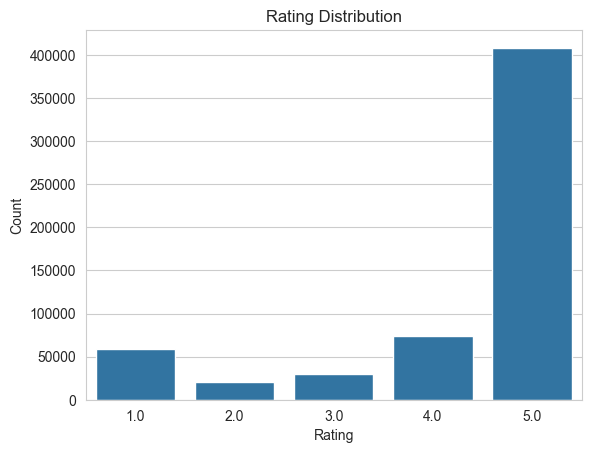

In [45]:
sns.countplot(x="overall", data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [46]:
# Rating proportions

df["overall"].value_counts(normalize=True)

overall
5.0    0.691107
4.0    0.124947
1.0    0.099121
3.0    0.050324
2.0    0.034500
Name: proportion, dtype: float64

In [47]:
### User Activity Distribution

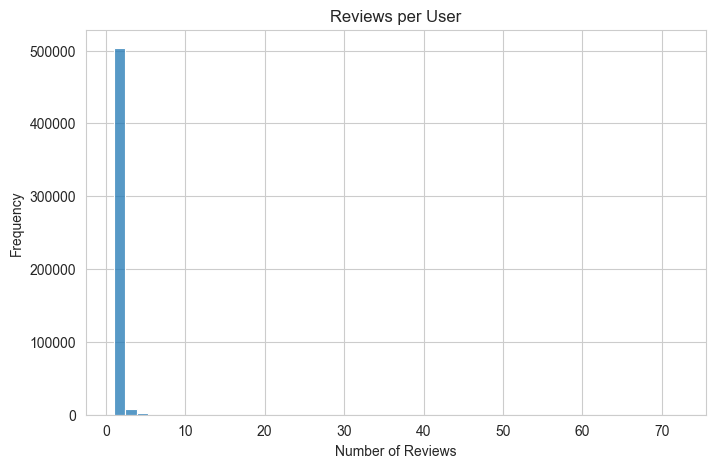

In [48]:
user_counts = df["reviewerID"].value_counts()

plt.figure(figsize=(8,5))
sns.histplot(user_counts, bins=50)
plt.title("Reviews per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

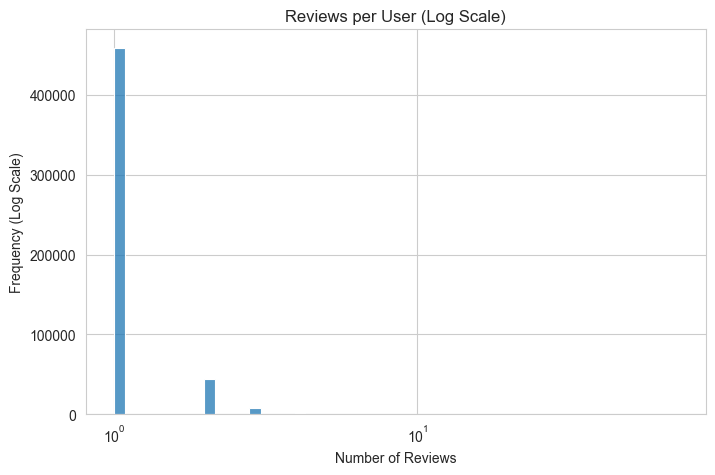

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(user_counts, bins=50, log_scale=True)
plt.title("Reviews per User (Log Scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency (Log Scale)")
plt.show()

In [50]:
# User statistics

print("Avg reviews per user:", user_counts.mean())
print("Median reviews per user:", user_counts.median())

# Cold start analysis
single_review_users = (user_counts == 1).sum()
total_users = len(user_counts)

print("Users with 1 review (%):", single_review_users / total_users)

Avg reviews per user: 1.1467821369110223
Median reviews per user: 1.0
Users with 1 review (%): 0.8906008049023755


In [51]:
### Item Popularity Distribution

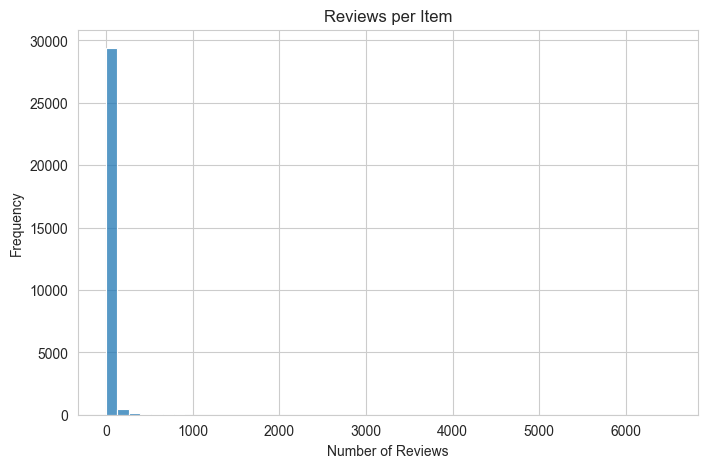

In [52]:
item_counts = df["asin"].value_counts()

plt.figure(figsize=(8,5))
sns.histplot(item_counts, bins=50)
plt.title("Reviews per Item")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

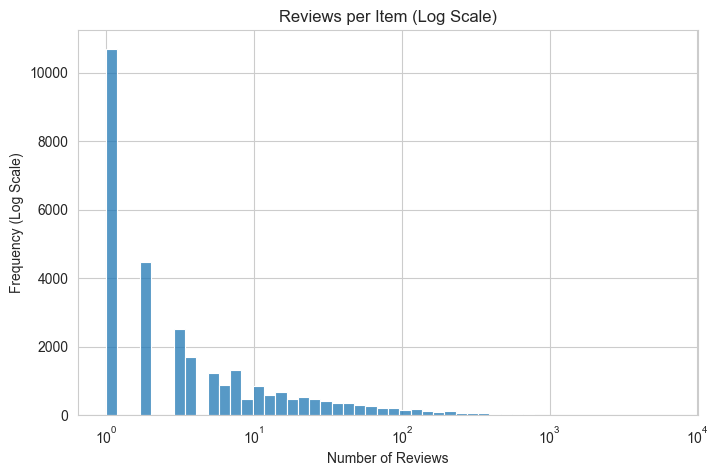

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(item_counts, bins=50, log_scale=True)
plt.title("Reviews per Item (Log Scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency (Log Scale)")
plt.show()

In [54]:
# Item statistics

print("Avg reviews per item:", item_counts.mean())
print("Median reviews per item:", item_counts.median())

Avg reviews per item: 19.538631930439383
Median reviews per item: 2.0


In [55]:
# Percentile Distribution

item_counts.describe(percentiles=[0.5, 0.9, 0.99])

count    30247.000000
mean        19.538632
std         99.473130
min          1.000000
50%          2.000000
90%         31.000000
99%        323.000000
max       6509.000000
Name: count, dtype: float64

In [56]:
# Popularity concentration

top_10_percent_items = int(0.1 * len(item_counts))
top_items_interactions = item_counts.head(top_10_percent_items).sum()

print("Top 10% items contribution:",
      top_items_interactions / n_interactions)

Top 10% items contribution: 0.7856256926994764


### Long Tail Distribution

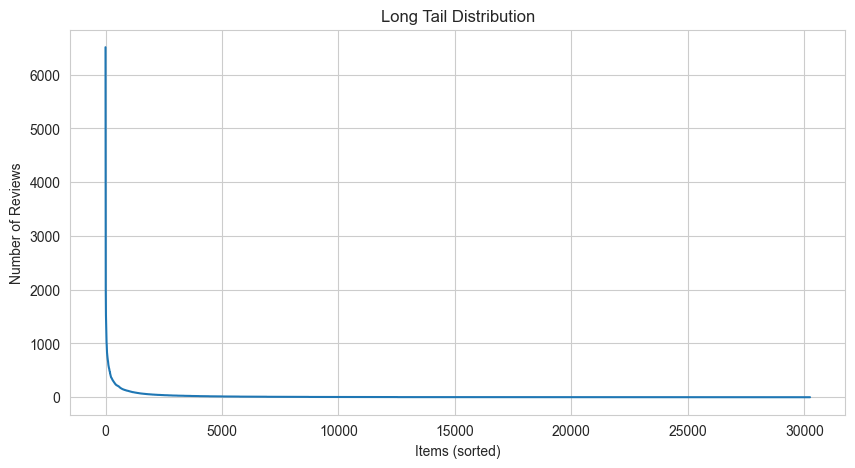

In [57]:
item_counts_sorted = item_counts.sort_values(ascending=False).values

plt.figure(figsize=(10,5))
plt.plot(item_counts_sorted)
plt.title("Long Tail Distribution")
plt.xlabel("Items (sorted)")
plt.ylabel("Number of Reviews")
plt.show()

### Long Tail (Log Scale)

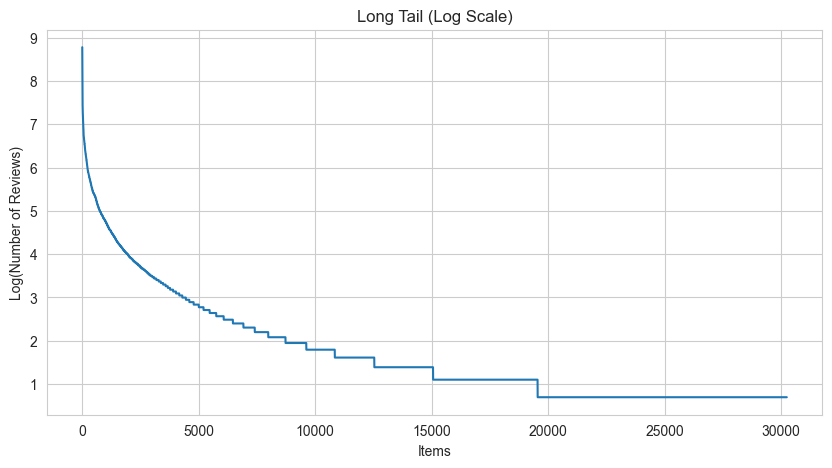

In [58]:
import numpy as np

plt.figure(figsize=(10,5))
plt.plot(np.log1p(item_counts_sorted))
plt.title("Long Tail (Log Scale)")
plt.xlabel("Items")
plt.ylabel("Log(Number of Reviews)")
plt.show()

### Most Active Users

In [59]:
user_counts.head(10)

reviewerID
A3GP2HMB2AFOKF    72
A1NOI52YK8RCM7    58
A23KSPVPHZF6EO    55
AFUVGAUNQVT0S     54
A31Z7V5X5A3QYU    39
A3H61AMBJ177DG    35
A1THBF0FCV9D54    32
A2SEK167AI6DZM    31
AISAWDZHCGIOG     30
A2HYAHPDFC3CB5    28
Name: count, dtype: int64

### Most Popular Items

In [62]:
top_items = (
    df.groupby(["asin", "title"])
      .size()
      .reset_index(name="review_count")
      .sort_values(by="review_count", ascending=False)
)

top_items = top_items.reset_index(drop=True)
top_items[["title", "review_count"]].head(10)

,title,review_count
0,General Electric MWF Refrigerator Water Filter,6509
1,Samsung Genuine DA29-00020B Refrigerator Water...,5698
2,GE MWF SmartWater Compatible Water Filter Cart...,3199
3,Frigidaire WF3CB Puresource Replacement Filter...,2933
4,AcuRite 00611A3 Wireless Indoor/Outdoor Thermo...,2480
5,"Compact Ice Maker, Red",2331
6,EcoAqua DA29-00020B Replacement for Samsung Wa...,2314
7,INFINITIPRO BY CONAIR Spin Air Rotating Styler...,2229
8,ThermoPro TP50 Digital Hygrometer Indoor Therm...,2204
9,"LG LT700P Refrigerator Water Filter, Filters u...",2032


### Missing Values Summary

In [63]:
df.isnull().sum()

reviewerID          0
asin                0
overall             0
reviewText          0
summary           120
reviewTime          0
title             993
brand            5910
category_list       0
category_text       0
description         0
dtype: int64

### Review Activity Over Time

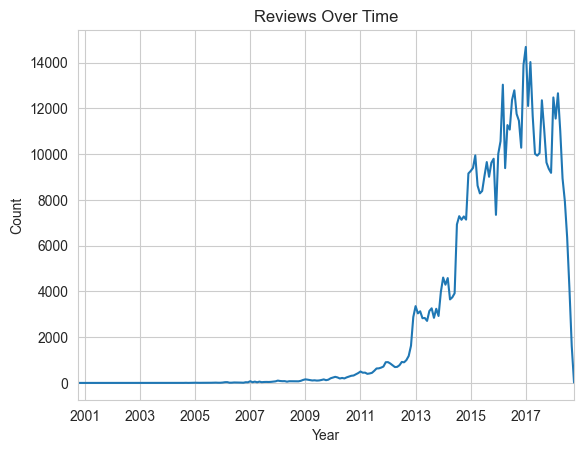

In [64]:
df["reviewTime"] = pd.to_datetime(df["reviewTime"], errors="coerce")

df.groupby(df["reviewTime"].dt.to_period("M")).size().plot()

plt.title("Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

## 📊 Final Insights from Exploratory Data Analysis

### 1. Dataset Overview
- Total interactions: ~590K
- Unique users: ~515K
- Unique items: ~30K
- Extremely high user count relative to interactions → sparse behavior

---

### 2. Sparsity
- Dataset sparsity ≈ 99.99%
- Most user-item pairs are unobserved
- Indicates severe data sparsity challenge

---

### 3. User Behavior (Cold Start)
- Majority of users have only 1 interaction
- Very few users are highly active
- Strong **user cold-start problem**
- Limits effectiveness of user-based collaborative filtering

---

### 4. Item Popularity (Long Tail)
- Item interactions follow a **power-law (long-tail) distribution**
- Few items dominate interactions
- Most items have very low visibility
- Leads to:
  - Popularity bias
  - Poor recommendation coverage

---

### 5. Rating Distribution
- Ratings heavily skewed toward 4–5 stars
- Indicates:
  - Positive feedback bias
  - Reduced variance in rating prediction
- Suggests ranking-based models over regression

---

### 6. Interaction Distribution
- Median interactions per user ≈ 1
- Median interactions per item is low
- Confirms extreme sparsity and imbalance

---

### 7. Temporal Trends
- Review activity increases over time
- Indicates platform growth
- Possible **concept drift** in user preferences

---

### 8. Modeling Implications

Due to dataset characteristics:

❌ User-based CF → weak (cold-start + sparsity)  
❌ Matrix factorization → limited signal  

✅ Content-based methods → strong candidate  
✅ NLP (TF-IDF, BERT) → highly relevant  
✅ Hybrid models → best approach  

---

### ✅ Final Conclusion

This dataset is a classic **high-sparsity, long-tail recommendation problem**, where:

👉 Content-based + NLP-driven approaches  
👉 Combined with collaborative signals  

/var/folders/b5/0ntz0lrj57q18drsl8xwddm00000gn/T/ipykernel_34035/3280140329.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="overall", data=df, palette=PALETTE, ax=ax1)
/var/folders/b5/0ntz0lrj57q18drsl8xwddm00000gn/T/ipykernel_34035/3280140329.py:72: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x="overall", data=df, palette=PALETTE, ax=ax1)
/var/folders/b5/0ntz0lrj57q18drsl8xwddm00000gn/T/ipykernel_34035/3280140329.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/b5/0ntz0lrj57q18drsl8xwddm00000gn/T/ipykernel_34035/3280140329.py:107: FutureWarning: 

Passing `palette

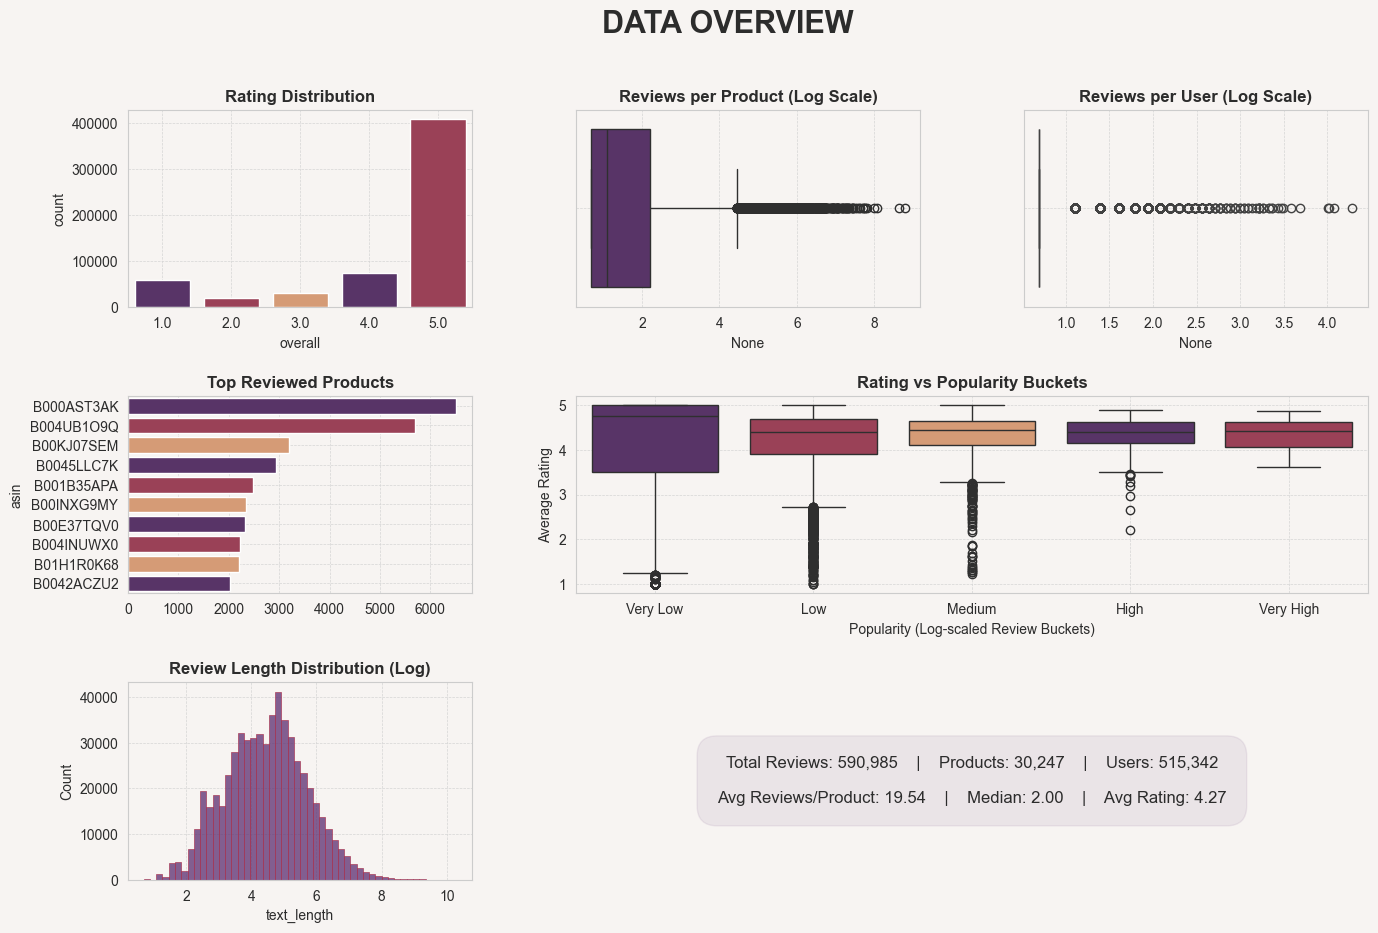

In [7]:
# ==========================================
# 🔥 FINAL EDA DASHBOARD (ERROR-FREE + POLISHED)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 🎨 COLOR PALETTE (CONSISTENT)
# ------------------------------
PRIMARY = "#5B2C6F"
SECONDARY = "#A9324F"
ACCENT = "#E59866"
LIGHT = "#F7F4F2"
DARK = "#2C2C2C"
GRID = "#D5D5D5"

PALETTE = [PRIMARY, SECONDARY, ACCENT]

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": LIGHT,
    "axes.facecolor": LIGHT,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
})

# ------------------------------
# 📥 LOAD DATA
# ------------------------------
df = pd.read_csv("../data/processed/cleaned_data.csv")

# ------------------------------
# 🧠 FEATURE ENGINEERING
# ------------------------------
product_counts = df.groupby("asin").size()
user_counts = df.groupby("reviewerID").size()

product_df = df.groupby("asin").agg({
    "overall": "mean",
    "reviewText": "count"
}).rename(columns={
    "overall": "avg_rating",
    "reviewText": "review_count"
})

df["text_length"] = df["reviewText"].astype(str).apply(len)

# 🔥 LOG-BASED BUCKETING (NO ERROR)
product_df["review_bucket"] = pd.cut(
    np.log1p(product_df["review_count"]),
    bins=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# ------------------------------
# 📊 FIGURE SETUP
# ------------------------------
fig = plt.figure(figsize=(16,10))
fig.suptitle("DATA OVERVIEW", fontsize=22, weight="bold")

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.3)

# ------------------------------
# 1. Rating Distribution
# ------------------------------
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(x="overall", data=df, palette=PALETTE, ax=ax1)
ax1.set_title("Rating Distribution", weight="bold")

# ------------------------------
# 2. Reviews per Product
# ------------------------------
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x=np.log1p(product_counts), color=PRIMARY, ax=ax2)
ax2.set_title("Reviews per Product (Log Scale)", weight="bold")

# ------------------------------
# 3. Reviews per User
# ------------------------------
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(x=np.log1p(user_counts), color=SECONDARY, ax=ax3)
ax3.set_title("Reviews per User (Log Scale)", weight="bold")

# ------------------------------
# 4. Top Reviewed Products
# ------------------------------
ax4 = fig.add_subplot(gs[1, 0])
top_products = product_counts.sort_values(ascending=False).head(10)
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette=sns.color_palette(PALETTE, len(top_products)),
    ax=ax4
)
ax4.set_title("Top Reviewed Products", weight="bold")

# ------------------------------
# 🔥 5. Rating vs Popularity (FIXED)
# ------------------------------
ax5 = fig.add_subplot(gs[1, 1:])

sns.boxplot(
    x="review_bucket",
    y="avg_rating",
    data=product_df,
    palette=PALETTE,
    ax=ax5
)

ax5.set_title("Rating vs Popularity Buckets", weight="bold")
ax5.set_xlabel("Popularity (Log-scaled Review Buckets)")
ax5.set_ylabel("Average Rating")

# ------------------------------
# 6. Review Length Distribution
# ------------------------------
ax6 = fig.add_subplot(gs[2, 0])
sns.histplot(
    np.log1p(df["text_length"]),
    bins=50,
    color=PRIMARY,
    edgecolor=SECONDARY,
    ax=ax6
)
ax6.set_title("Review Length Distribution (Log)", weight="bold")

# ------------------------------
# 🔥 7. CENTERED STATS PANEL (FIXED)
# ------------------------------
ax7 = fig.add_subplot(gs[2, 1:])
ax7.axis("off")

stats_text = (
    f"Total Reviews: {len(df):,}    |    "
    f"Products: {df['asin'].nunique():,}    |    "
    f"Users: {df['reviewerID'].nunique():,}\n\n"
    f"Avg Reviews/Product: {product_counts.mean():.2f}    |    "
    f"Median: {product_counts.median():.2f}    |    "
    f"Avg Rating: {df['overall'].mean():.2f}"
)

ax7.text(
    0.5, 0.5,
    stats_text,
    fontsize=12,
    ha="center",
    va="center",
    bbox=dict(
        facecolor=PRIMARY,
        alpha=0.08,
        edgecolor=PRIMARY,
        boxstyle="round,pad=1.2"
    )
)

# ------------------------------
# CLEANUP
# ------------------------------
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.grid(True, linestyle="--", linewidth=0.5, color=GRID)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()